# Bibliotécas

In [1]:
import pandas                                       as pd
import numpy                                        as np
import xgboost                                      as xgb
import seaborn                                      as sns
import matplotlib                                   as mpl 
from sklearn                 import model_selection as ms
from matplotlib              import pyplot          as plt
from sklearn                 import linear_model    as lm
from sklearn                 import metrics         as mt
from sklearn                 import preprocessing   as pp
from statsmodels             import api             as sm
from matplotlib.gridspec     import GridSpec
from sklearn.linear_model    import Lasso, Ridge
from skopt                   import BayesSearchCV
from skopt.space             import Real, Categorical, Integer
from sklearn.svm             import SVR
from sklearn.dummy           import DummyRegressor
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble        import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics         import make_scorer, mean_absolute_error, mean_squared_error
from IPython.display         import HTML
from ydata_profiling         import ProfileReport
from google.cloud            import storage
import pickle
import inflection
import warnings
%matplotlib inline

warnings.filterwarnings('ignore')

mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'
mpl.rcParams['grid.color'] = 'lightgray'
mpl.rcParams['axes.grid'] = True
mpl.rcParams['font.size'] = 12

#Configurando as paleta de cores
color_palette = ['#023047', '#e85d04', '#0077b6', '#ff8200', '#0096c7', '#ff9c33']
sns.set_palette(sns.color_palette(color_palette))

#Cores utilizadas
sns.color_palette(color_palette)

[(0.00784313725490196, 0.18823529411764706, 0.2784313725490196),
 (0.9098039215686274, 0.36470588235294116, 0.01568627450980392),
 (0.0, 0.4666666666666667, 0.7137254901960784),
 (1.0, 0.5098039215686274, 0.0),
 (0.0, 0.5882352941176471, 0.7803921568627451),
 (1.0, 0.611764705882353, 0.2)]

# Funções

In [2]:
#from IPython.display import HTML
def jupyter_settings():
    %matplotlib inline

    plt.style.use('ggplot')
    plt.rcParams['figure.figsize'] = [20, 9]
    plt.rcParams['font.size'] = 24

    display(HTML('<style>.container{width: 100% !important;}</style>'))
    
    pd.options.display.max_rows = None
    pd.options.display.max_columns = None
    pd.set_option('display.expand_frame_repr', False)

    sns.set()

    # Aumenta a quantidade de texto mostrado nas células de saída
    from IPython.core.interactiveshell import InteractiveShell
    InteractiveShell.ast_node_interactivity = 'all'
jupyter_settings()

#import inflection
def renomear_colunas(df):
    title = lambda x: inflection.titleize(x)
    snakecase = lambda x: inflection.underscore(x)
    spaces = lambda x: x.replace(" ", "")
    cols_old = list(df.columns)
    cols_old = list(map(title, cols_old))
    cols_old = list(map(spaces, cols_old))
    cols_new = list(map(snakecase, cols_old))
    df.columns = cols_new
    return df

def descricao_estatistica(df):
    #Métricas de tendência central: média e mediana
    central_1 = pd.DataFrame(df.apply(np.mean)).T
    central_2 = pd.DataFrame(df.apply(np.median)).T
    
    #Métricas de dispersão: desvio padrão, mínimo, máximo, aplitude, assimetrica e curtose
    dispersao_1 = pd.DataFrame(df.apply(np.std)).T
    dispersao_2 = pd.DataFrame(df.apply(np.min)).T
    dispersao_3 = pd.DataFrame(df.apply(np.max)).T
    dispersao_4 = pd.DataFrame(df.apply(lambda x: x.max() - x.min())).T
    dispersao_5 = pd.DataFrame(df.apply(lambda x: x.skew())).T
    dispersao_6 = pd.DataFrame(df.apply(lambda x: x.kurtosis())).T
    
    metricas = pd.concat([dispersao_2, dispersao_3, dispersao_4, central_1, central_2, dispersao_1, dispersao_5, dispersao_6]).T
    metricas.columns = ['min', 'max', 'amplitude', 'mean', 'median', 'std', 'assimetria', 'kurtosis']
    return metricas

def converter_para_int(dataframe: pd.DataFrame, nome_coluna: str) -> bool:
    """
    Descrição:
        Converter a coluna especificada em um dataframe para tipo inteiro
    
    Argumentos:
        dataframe (pd.DataFrame): O dataframe a ser processado
        nome_coluna (str): O nome da coluna a ser convertida
    
    Returns:
        booleano: True se a conversão foi bem sucedida
    """
    try:
        dataframe[nome_coluna] = dataframe[nome_coluna].astype(int)
        return True
    except ValueError:
        print(f"Erro: Não foi possível converter a coluna '{nome_coluna}' para tipo inteiro.")
        return False

def converter_para_data(dataframe: pd.DataFrame, nome_coluna: str, formato_data: str = None) -> bool:
    """
    Descrição:
        Converter a coluna especificada em um dataframe para tipo data
    
    Argumentos:
        dataframe (pd.DataFrame): O dataframe a ser processado
        nome_coluna (str): O nome da coluna a ser convertida
    
    Returns:
        booleano: True se a conversão foi bem sucedida
    """
    try:
        dataframe[nome_coluna] = pd.to_datetime(dataframe[nome_coluna])
        return True
    except ValueError:
        print(f"Erro: Não foi possível converter a coluna '{nome_coluna}' para tipo de data.")
        return False

    #from sklearn.model_selection import KFold
#from sklearn.metrics import mean_absolute_error, mean_squared_error    
def ml_error(y, y_pred, desvpad = True):
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y))
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    std_mae = np.std(np.abs(y - y_pred))
    std_mape = np.std(np.abs((y - y_pred) / y))
    std_rmse = np.std(np.abs(y - y_pred))    
    if desvpad:
        return pd.DataFrame({'mae': f"{mae:.2f} +/- {std_mae:.2f}", 
                             'mape': f"{mape:.2f} +/- {std_mape:.2f}",
                             'rmse': f"{rmse:.2f} +/- {std_rmse:.2f}"}, index = [0])
    else:
        return pd.DataFrame({'mae': f"{mae:.2f}",
                             'mape': f"{mape:.2f}",
                             'rmse': f"{rmse:.2f}"}, index = [0])

def validacao_cruzada(modelo, x, y, desvpad = True, verbose = True):
    kfold = KFold(n_splits=5)
    
    resultados = []

    for idx, (treino_idx, validacao_idx) in enumerate(kfold.split(x, y)):
        
        if verbose:
            linha_inicial = validacao_idx[0]
            linha_final = validacao_idx[-1]
            print(f"Fold {idx}: {linha_inicial} - {linha_final}")
        
        if isinstance(x, np.ndarray):
            x_treino_fold, x_validacao_fold = x[treino_idx], x[validacao_idx]
        else:
            x_treino_fold, x_validacao_fold = x.iloc[treino_idx], x.iloc[validacao_idx]

        if isinstance(y, np.ndarray):
            y_treino_fold, y_validacao_fold = y[treino_idx], y[validacao_idx]
        else:
            y_treino_fold, y_validacao_fold = y.iloc[treino_idx], y.iloc[validacao_idx]

        modelo.fit(x_treino_fold, y_treino_fold)
        y_pred = modelo.predict(x_validacao_fold)

        mae = mean_absolute_error(np.expm1(y_validacao_fold), np.expm1(y_pred))
        mape = np.mean(np.abs((np.expm1(y_validacao_fold) - np.expm1(y_pred)) / np.expm1(y_validacao_fold)))
        rmse = np.sqrt(mean_squared_error(np.expm1(y_validacao_fold), np.expm1(y_pred)))
        std_mae = np.std(np.abs(np.expm1(y_validacao_fold) - np.expm1(y_pred)))
        std_mape = np.std(np.abs((np.expm1(y_validacao_fold) - np.expm1(y_pred)) / np.expm1(y_validacao_fold)))
        std_rmse = np.std(np.abs(np.expm1(y_validacao_fold) - np.expm1(y_pred)))    
        
        resultado = {'mae': mae, 
                     'mape': mape,
                     'rmse': rmse,
                     'std_mae': std_mae,
                     'std_mape': std_mape,
                     'std_rmse': std_rmse}
        
        resultados.append(resultado)

    # Calculando a média e o desvio padrão para cada métrica em todos os folds
    mean_resultados = {metrica: np.mean([r[metrica] for r in resultados]) for metrica in resultados[0]}
    std_resultados = {metrica: np.std([r[metrica] for r in resultados]) for metrica in resultados[0]}
    
    if desvpad:
        return pd.DataFrame({'algoritmo': modelo.__class__.__name__,
                             'mae_cv': f"{mean_resultados['mae']:.2f} +/- {std_resultados['std_mae']:.2f}",
                             'mape_cv': f"{mean_resultados['mape']:.2f} +/- {std_resultados['std_mape']:.2f}",
                             'rmse_cv': f"{mean_resultados['rmse']:.2f} +/- {std_resultados['std_rmse']:.2f}"}, index = [0])
    else:
        return pd.DataFrame({'algoritmo': modelo.__class__.__name__,
                             'mae_cv': f"{mean_resultados['mae']:.2f}",
                             'mape_cv': f"{mean_resultados['mape']:.2f}",
                             'rmse_cv': f"{mean_resultados['rmse']:.2f}"}, index = [0])

# 1. (Limpeza dos dados) Passo 1: Descrição dos dados

### 1.1 Descrição do desafio

#### Você recebeu uma tarefa de criar um modelo de machine learning para auxiliar uma construtora a medir a resistência do concreto,
#### pois eles dependem dessa questão para construir os seus projetos, e a equipe de engenheiros está interessada em prever a
#### resistência do concreto, que é a parte mais importante da constução civil, dado algumas características que eles têm disponíveis. 

#### 1.7.1 Descrição das colunas

**Cement (Cimento):** O cimento é um dos principais componentes do concreto. Ele é responsável por ligar os outros materiais, como agregados, e formar uma massa coesa. O tipo e a quantidade de cimento utilizados podem influenciar significativamente a resistência do concreto.

**Slag (Escarpa):** Slag, ou escarpa, é um subproduto da produção de aço, frequentemente usado como componente do cimento ou como adição ao concreto. Sua presença pode afetar propriedades como resistência e durabilidade.

**Flyash (Cinzas volantes):** Cinzas volantes são subprodutos resultantes da queima de carvão em usinas termoelétricas. Elas podem ser usadas como adição ao cimento ou ao concreto, proporcionando benefícios como melhoria da trabalhabilidade, redução do calor de hidratação e aumento da durabilidade.

**Water (Água):** A água é um componente essencial do concreto, pois é necessária para a hidratação do cimento, que é o processo pelo qual o cimento reage quimicamente e endurece. A quantidade de água utilizada afeta a trabalhabilidade e a resistência do concreto.

**Superplasticizer (Superplastificante):** Superplastificantes são aditivos químicos adicionados ao concreto para melhorar sua trabalhabilidade sem aumentar significativamente a quantidade de água. Eles permitem a redução da relação água/cimento, o que pode resultar em concretos mais resistentes e duráveis.

**Coarse Aggregate (Agregado graúdo):** Os agregados graúdos são partículas de materiais como pedra britada, cascalho ou pedregulho, que são adicionados ao concreto para aumentar sua resistência. Eles fornecem suporte estrutural e ajudam a reduzir a quantidade de pasta de cimento necessária.

**Fine Aggregate (Agregado fino):** Os agregados finos são partículas de materiais como areia ou pó de pedra, que são adicionados ao concreto para preencher os espaços entre os agregados graúdos e melhorar a trabalhabilidade.

**Age (Idade em dias):** A idade do concreto se refere ao tempo decorrido desde sua mistura inicial até o momento da avaliação. A idade do concreto pode afetar sua resistência e outras propriedades, uma vez que o processo de cura e endurecimento continua ao longo do tempo.

**csMPa (Resistência Compressiva em Megapascal):** Este é o atributo alvo que o modelo de previsão deve estimar. Representa a resistência do concreto à compressão, medida em megapascal (MPa). É uma medida crítica da qualidade e da adequação do concreto para determinadas aplicações na construção civil.

### 1.2 Carregar os dados

In [3]:
%%bigquery df_raw

SELECT * FROM `pro-plasma-414522.qualidade_concreto.dados`

Query is running:   0%|          |

Downloading:   0%|          |

In [4]:
df1 = df_raw.copy()

In [5]:
df1.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,144.0,0.0,175.0,158.0,18.0,943.0,844.0,28,15.42
1,152.0,178.0,139.0,168.0,18.0,944.0,695.0,28,36.35
2,336.5,0.0,0.0,181.9,3.4,985.8,816.8,28,44.87
3,321.0,164.0,0.0,190.0,5.0,870.0,774.0,28,57.21
4,385.0,0.0,136.0,158.0,20.0,903.0,768.0,28,55.55


#### 1.2.1 Separar em treino e teste

In [6]:
x = df1.drop('csMPa', axis = 1)
y = df1['csMPa'].copy()

x_treino, x_teste, y_treino, y_teste = ms.train_test_split(x, y, test_size = 0.2, random_state = 42)

df1 = pd.concat([x_treino, y_treino], axis = 1)

In [7]:
print('x_treino: {}'.format(x_treino.shape))
print('x_teste: {}'.format(x_teste.shape))
print('\ny_treino: {}'.format(y_treino.shape))
print('y_teste: {}'.format(y_teste.shape))

x_treino: (824, 8)
x_teste: (206, 8)

y_treino: (824,)
y_teste: (206,)


### 1.3 Dimensão dos dados

In [8]:
df1.shape

(824, 9)

In [9]:
df1.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
995,212.6,0.0,100.4,159.4,10.4,1003.8,903.8,56,44.40
507,288.0,121.0,0.0,177.0,7.0,908.0,829.0,28,42.13
334,333.0,0.0,0.0,192.0,0.0,931.2,842.6,28,31.97
848,252.3,0.0,98.8,146.3,14.2,987.8,889.0,14,42.29
294,475.0,0.0,0.0,228.0,0.0,932.0,594.0,270,42.13


In [10]:
x_teste.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
31,149.0,236.0,0.0,176.0,13.0,847.0,893.0,28
109,480.0,0.0,0.0,192.0,0.0,936.0,721.0,3
136,307.0,0.0,0.0,193.0,0.0,968.0,812.0,90
88,200.0,133.0,0.0,192.0,0.0,965.4,806.2,3
918,318.8,212.5,0.0,155.7,14.3,852.1,880.4,56


### <s>1.4 Editar as colunas</s>

### 1.5 Tipo de dados

In [11]:
df1.dtypes

cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   Int64
csMPa               float64
dtype: object

#### <s>1.5.1 Editar os tipos de dados</s>

### 1.6 Verificar NA's

In [12]:
df1.isna().sum()

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

#### <s>1.6.1 Tratar NA's</s>

#### <s>1.6.2 Verificar NA's novamente</s>

### 1.7 Descrição estatística do negócio

In [13]:
descricao_estatistica(df1)

,min,max,amplitude,mean,median,std,assimetria,kurtosis
cement,102.00,540.0,438.00,284.841869,275.100,107.317321,0.488937,-0.594667
slag,0.00,359.4,359.40,72.754612,22.000,86.599910,0.860743,-0.385444
flyash,0.00,200.1,200.10,52.416019,0.000,63.778739,0.600588,-1.252676
water,121.80,247.0,125.20,181.375607,185.700,21.177877,0.030554,0.170535
superplasticizer,0.00,32.2,32.20,6.096481,6.100,5.943227,0.910720,1.318148
coarseaggregate,801.00,1145.0,344.00,974.634466,968.000,77.537175,-0.021519,-0.603418
fineaggregate,594.00,992.6,398.60,773.821845,780.100,79.802368,-0.277751,-0.131310
age,1.00,365.0,364.00,45.949029,28.000,63.815894,3.238471,11.973051
csMPa,2.33,82.6,80.27,35.965522,34.675,16.891226,0.403182,-0.349256


# 2. (Limpeza dos dados) Passo 2: Engenharia de variáveis

In [14]:
df2 = df1.copy()

# 3. (Limpeza dos dados) Passo 3: Filtragem de variáveis (restrição do negócio)

In [15]:
df3 = df2.copy()

# 4. (Exploração dos dados) Passo 4: Análise exploratória dos dados

In [16]:
df4 = df3.copy()

### 4.1 Análise univariada

#### 4.1.1 Variável resposta

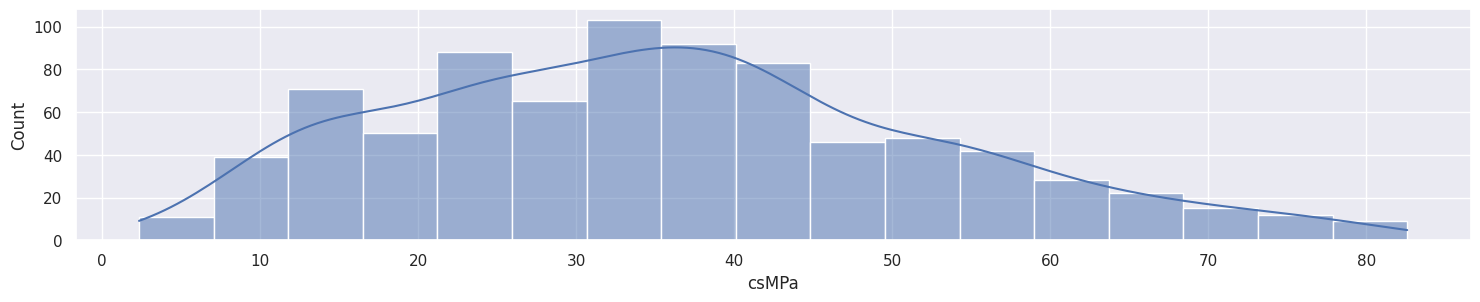

In [17]:
plt.figure(figsize = (18, 3)) #Ajuste o tamanho conforme necessário

#csMPa
sns.histplot(x = 'csMPa', data = df4, kde = True);

#### 4.1.2 Outras variáveis

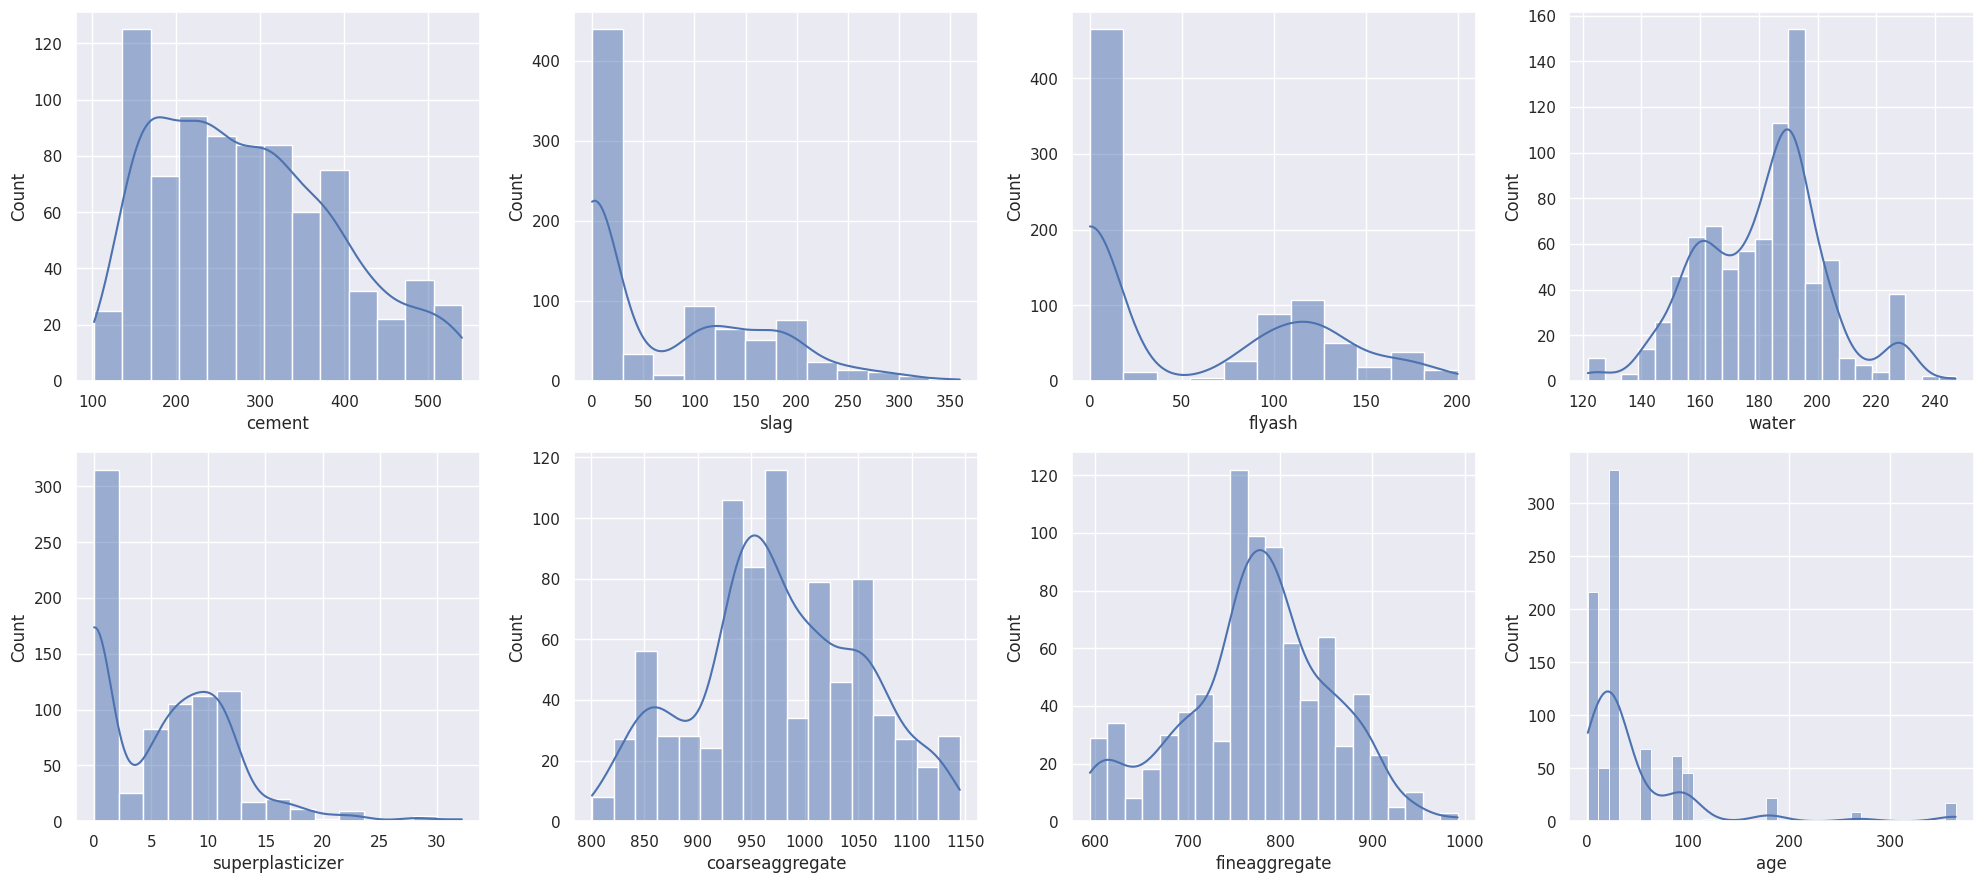

In [18]:
grid = GridSpec(2, 4) #Concatena os gráficos, neste caso precisarei de 2 linhas e 2 colunas

#cement
plt.subplot(grid[0, 0])
sns.histplot(x = 'cement', data = df4, kde = True)

#slag
plt.subplot(grid[0, 1])
sns.histplot(x = 'slag', data = df4, kde = True)

#flyash
plt.subplot(grid[0, 2])
sns.histplot(x = 'flyash', data = df4, kde = True)

#water
plt.subplot(grid[0, 3])
sns.histplot(x = 'water', data = df4, kde = True)

#superplasticizer
plt.subplot(grid[1, 0])
sns.histplot(x = 'superplasticizer', data = df4, kde = True)

#coarseaggregate
plt.subplot(grid[1, 1])
sns.histplot(x = 'coarseaggregate', data = df4, kde = True)

#fineaggregate
plt.subplot(grid[1, 2])
sns.histplot(x = 'fineaggregate', data = df4, kde = True)

#age
plt.subplot(grid[1, 3])
sns.histplot(x = 'age', data = df4, kde = True)

plt.tight_layout();

#### 4.1.3 Verificar se existem outliers

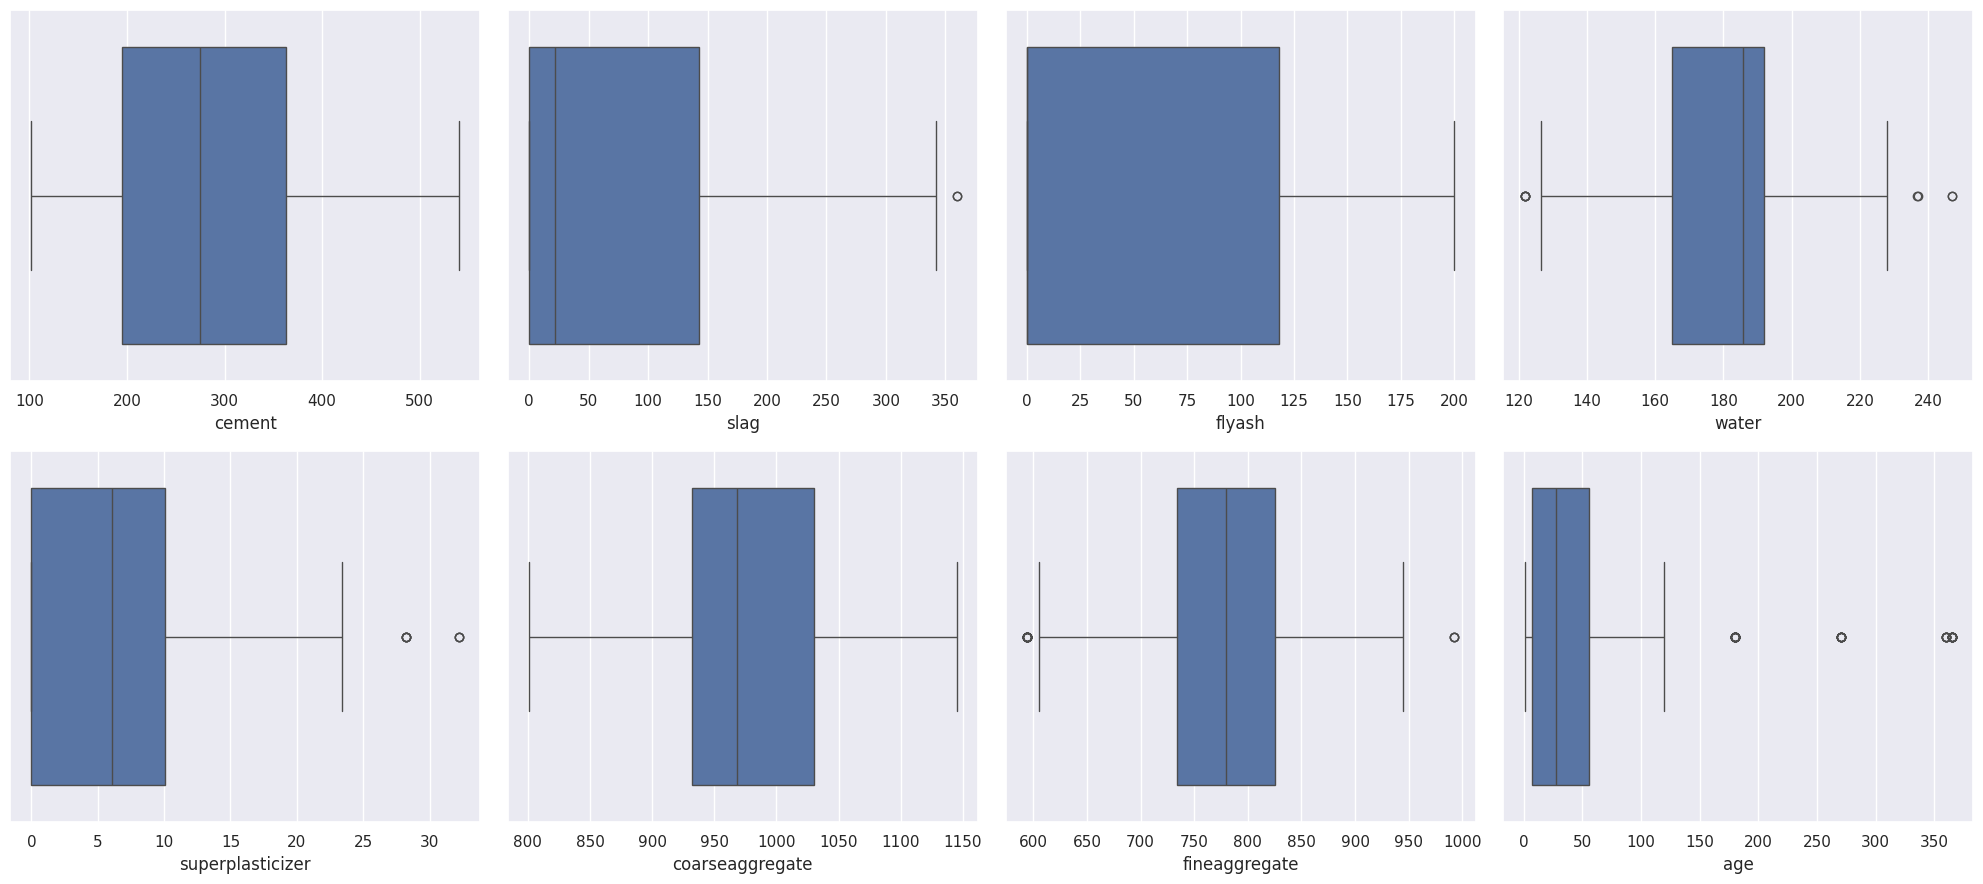

In [19]:
grid = GridSpec(2, 4) #Concatena os gráficos, neste caso precisarei de 2 linhas e 2 colunas

#cement
plt.subplot(grid[0, 0])
sns.boxplot(x = 'cement', data = df4)

#slag
plt.subplot(grid[0, 1])
sns.boxplot(x = 'slag', data = df4)

#flyash
plt.subplot(grid[0, 2])
sns.boxplot(x = 'flyash', data = df4)

#water
plt.subplot(grid[0, 3])
sns.boxplot(x = 'water', data = df4)

#superplasticizer
plt.subplot(grid[1, 0])
sns.boxplot(x = 'superplasticizer', data = df4)

#coarseaggregate
plt.subplot(grid[1, 1])
sns.boxplot(x = 'coarseaggregate', data = df4)

#fineaggregate
plt.subplot(grid[1, 2])
sns.boxplot(x = 'fineaggregate', data = df4)

#age
plt.subplot(grid[1, 3])
sns.boxplot(x = 'age', data = df4)

plt.tight_layout();

### A variável que possui mais outliers é a 'age', contudo as variáveis 'superplasticizer' e 'water' também mostram que possuem valores atípicos

#### 4.1.4 Verificar se as distribuições são normais

### 4.2 Análise bivariada

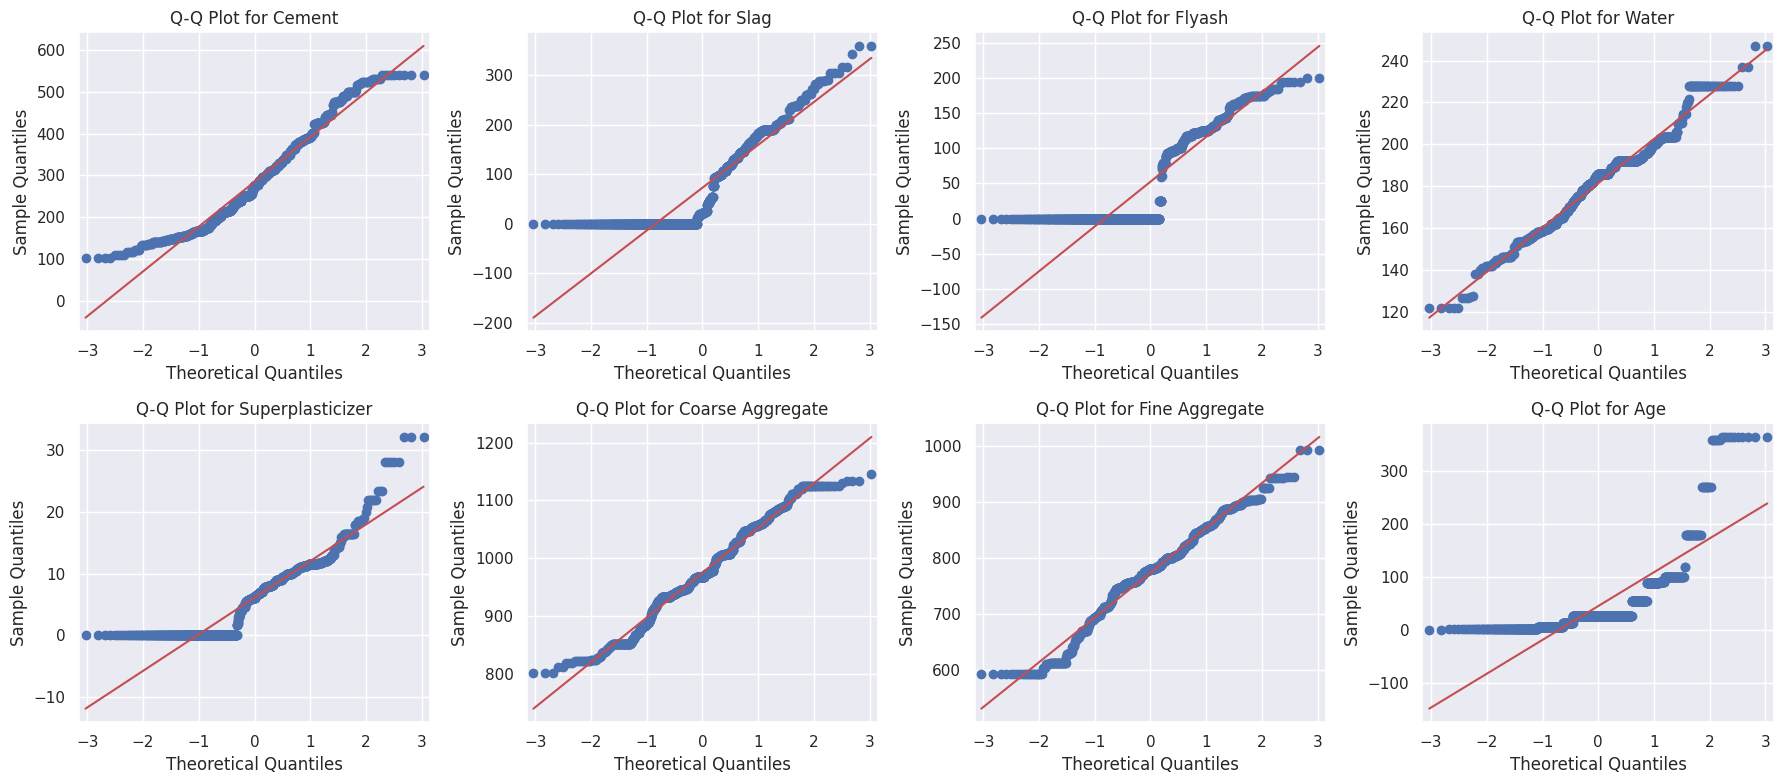

In [20]:
fig, axs = plt.subplots(2, 4, figsize = (18, 8))
grid = GridSpec(2, 4) #Concatena os gráficos, neste caso precisarei de 2 linhas e 2 colunas

#cement
axs[0, 0].set_title('Q-Q Plot for Cement')
sm.qqplot(df4['cement'], line='s', ax=axs[0, 0])

#slag
axs[0, 1].set_title('Q-Q Plot for Slag')
sm.qqplot(df4['slag'], line='s', ax=axs[0, 1])

#flyash
axs[0, 2].set_title('Q-Q Plot for Flyash')
sm.qqplot(df4['flyash'], line='s', ax=axs[0, 2])

#water
axs[0, 3].set_title('Q-Q Plot for Water')
sm.qqplot(df4['water'], line='s', ax=axs[0, 3])

#superplasticizer
axs[1, 0].set_title('Q-Q Plot for Superplasticizer')
sm.qqplot(df4['superplasticizer'], line='s', ax=axs[1, 0])

#coarseaggregate
axs[1, 1].set_title('Q-Q Plot for Coarse Aggregate')
sm.qqplot(df4['coarseaggregate'], line='s', ax=axs[1, 1])

#fineaggregate
axs[1, 2].set_title('Q-Q Plot for Fine Aggregate')
sm.qqplot(df4['fineaggregate'], line='s', ax=axs[1, 2])

#age
axs[1, 3].set_title('Q-Q Plot for Age')
sm.qqplot(df4['age'], line='s', ax=axs[1, 3])

plt.tight_layout()
plt.show();

### Quase todas as variáveis não possuem distribuição normal dos dados, somente a variável 'water' tem relativa distribuição gaussiana

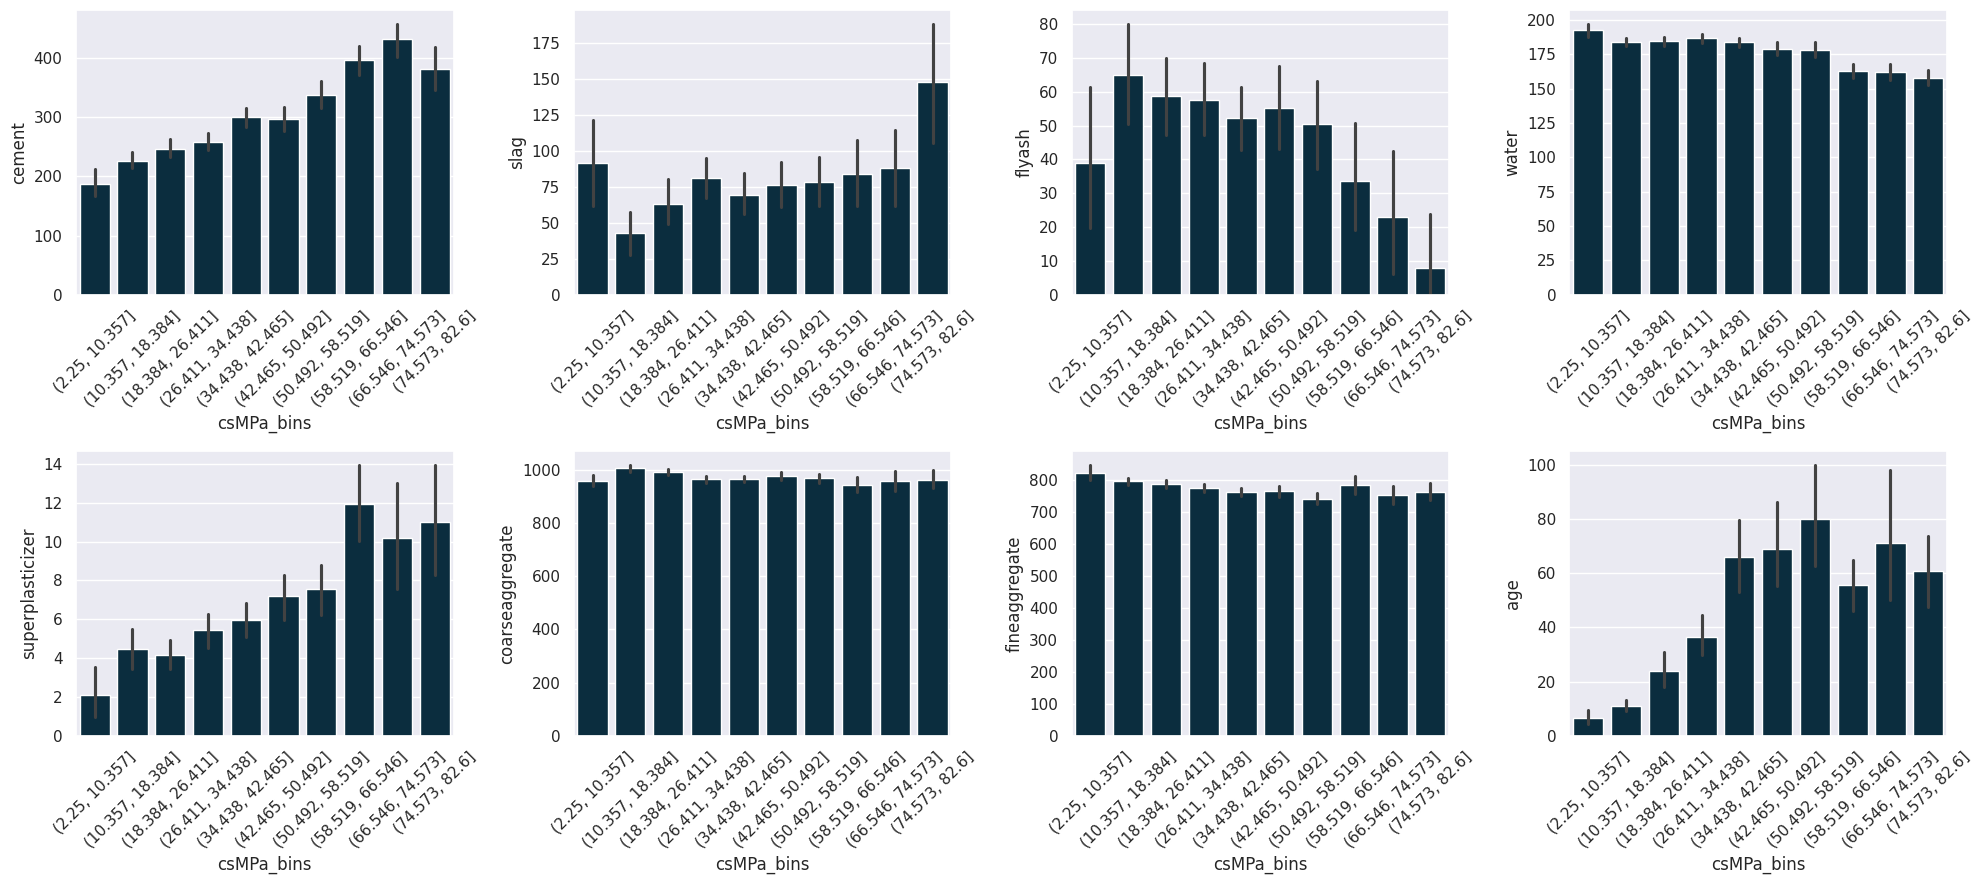

In [78]:
grid = GridSpec(2, 4) #Concatena os gráficos, neste caso precisarei de 2 linhas e 2 colunas

# Definindo a paleta de cores
color_palette = ['#023047', '#e85d04', '#0077b6', '#ff8200', '#0096c7', '#ff9c33']
sns.set_palette(sns.color_palette(color_palette))

# Dividindo os dados em 5 bins
df4['csMPa_bins'] = pd.cut(df4['csMPa'], bins = 10)

#cement
plt.subplot(grid[0, 0])
sns.barplot(x = 'csMPa_bins', y = 'cement', data = df4)
plt.xticks(rotation = 45)

#slag
plt.subplot(grid[0, 1])
sns.barplot(x = 'csMPa_bins', y = 'slag', data = df4)
plt.xticks(rotation = 45)

#flyash
plt.subplot(grid[0, 2])
sns.barplot(x = 'csMPa_bins', y = 'flyash', data = df4)
plt.xticks(rotation = 45)

#water
plt.subplot(grid[0, 3])
sns.barplot(x = 'csMPa_bins', y = 'water', data = df4)
plt.xticks(rotation = 45)

#superplasticizer
plt.subplot(grid[1, 0])
sns.barplot(x = 'csMPa_bins', y = 'superplasticizer', data = df4)
plt.xticks(rotation = 45)

#coarseaggregate
plt.subplot(grid[1, 1])
sns.barplot(x = 'csMPa_bins', y = 'coarseaggregate', data = df4)
plt.xticks(rotation = 45)

#fineaggregate
plt.subplot(grid[1, 2])
sns.barplot(x = 'csMPa_bins', y = 'fineaggregate', data = df4)
plt.xticks(rotation = 45)

#age
plt.subplot(grid[1, 3])
sns.barplot(x = 'csMPa_bins', y = 'age', data = df4)
plt.xticks(rotation = 45)

plt.tight_layout();

### As variáveis 'water', 'coarseaggregate' e 'fineaggregate' tem pouca variabilidade em relação a variável resposta

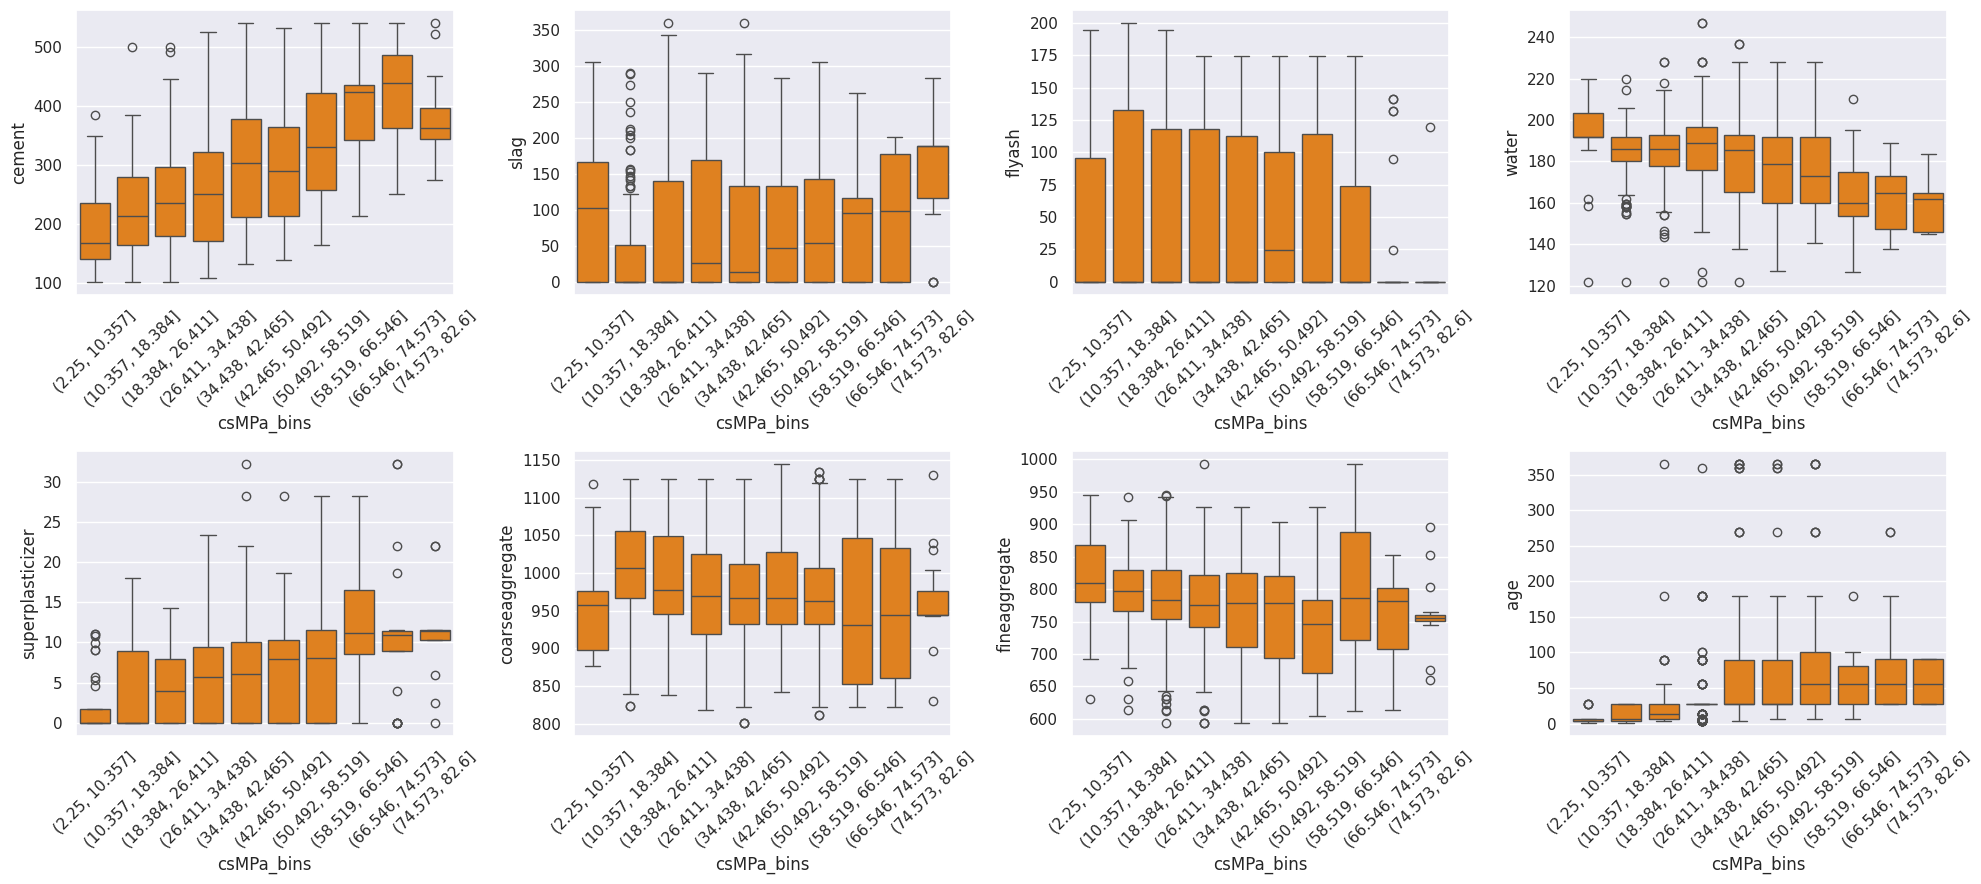

In [81]:
grid = GridSpec(2, 4) #Concatena os gráficos, neste caso precisarei de 2 linhas e 2 colunas

# Definindo a paleta de cores
color_palette = ['#ff8200', '#0096c7', '#ff9c33']
sns.set_palette(sns.color_palette(color_palette))

# Dividindo os dados em 5 bins
df4['csMPa_bins'] = pd.cut(df4['csMPa'], bins = 10)

#cement
plt.subplot(grid[0, 0])
sns.boxplot(x = 'csMPa_bins', y = 'cement', data = df4)
plt.xticks(rotation = 45)

#slag
plt.subplot(grid[0, 1])
sns.boxplot(x = 'csMPa_bins', y = 'slag', data = df4)
plt.xticks(rotation = 45)

#flyash
plt.subplot(grid[0, 2])
sns.boxplot(x = 'csMPa_bins', y = 'flyash', data = df4)
plt.xticks(rotation = 45)

#water
plt.subplot(grid[0, 3])
sns.boxplot(x = 'csMPa_bins', y = 'water', data = df4)
plt.xticks(rotation = 45)

#superplasticizer
plt.subplot(grid[1, 0])
sns.boxplot(x = 'csMPa_bins', y = 'superplasticizer', data = df4)
plt.xticks(rotation = 45)

#coarseaggregate
plt.subplot(grid[1, 1])
sns.boxplot(x = 'csMPa_bins', y = 'coarseaggregate', data = df4)
plt.xticks(rotation = 45)

#fineaggregate
plt.subplot(grid[1, 2])
sns.boxplot(x = 'csMPa_bins', y = 'fineaggregate', data = df4)
plt.xticks(rotation = 45)

#age
plt.subplot(grid[1, 3])
sns.boxplot(x = 'csMPa_bins', y = 'age', data = df4)
plt.xticks(rotation = 45)

plt.tight_layout();

### As variáveis 'flyash' e 'fineaggregate' apresentam pouca diferença em relação a sua média

### 4.3 Análise multivariada

In [23]:
#plt.figure(figsize = (18, 10))

#correlation = df4.corr(method = 'pearson')
#sns.heatmap(correlation, annot = True, cmap = 'coolwarm');

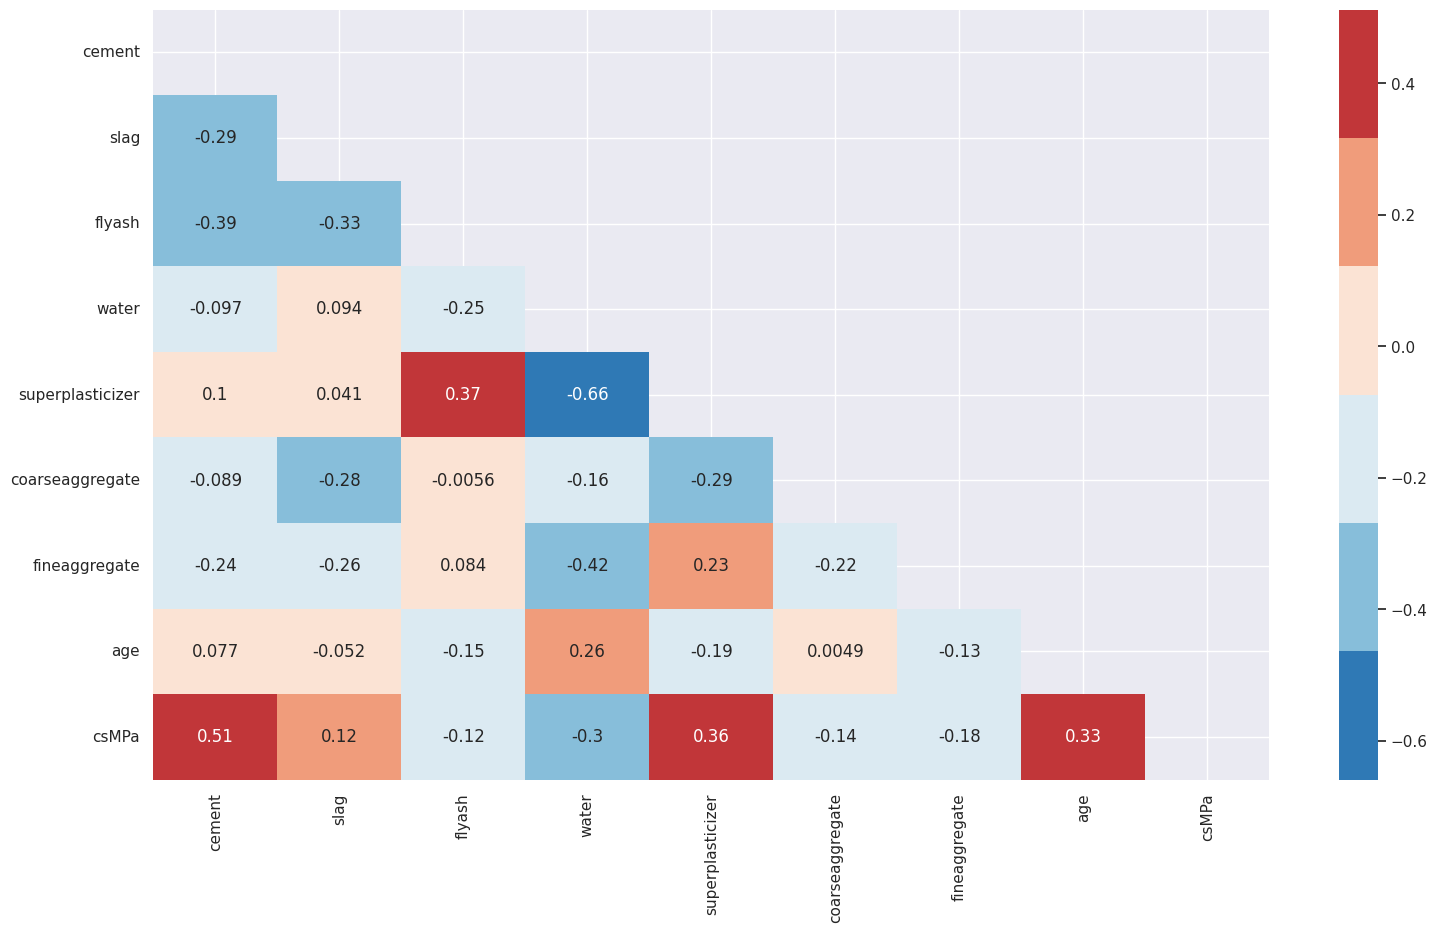

In [24]:
plt.figure(figsize = (18, 10))

correlation = df4.corr(method = 'pearson')
mask = np.triu(np.ones_like(correlation))

cmap = sns.color_palette('RdBu_r')

sns.heatmap(correlation, xticklabels = correlation.columns, yticklabels = correlation.columns, cmap = cmap, mask = mask, annot = True);

# 5. (Modelagem dos dados) Passo 5: Preparação dos dados

In [25]:
df5 = df4.copy()

### 5.1 Normalização

#### 5.1.1 Dados de treino

In [26]:
df5.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
995,212.6,0.0,100.4,159.4,10.4,1003.8,903.8,56,44.40
507,288.0,121.0,0.0,177.0,7.0,908.0,829.0,28,42.13
334,333.0,0.0,0.0,192.0,0.0,931.2,842.6,28,31.97
848,252.3,0.0,98.8,146.3,14.2,987.8,889.0,14,42.29
294,475.0,0.0,0.0,228.0,0.0,932.0,594.0,270,42.13


In [27]:
#MinMax Scaler
#cement
mms_cement = pp.MinMaxScaler()
df5['cement'] = mms_cement.fit_transform(df5[['cement']].values) 

#slag
mms_slag = pp.MinMaxScaler()
df5['slag'] = mms_slag.fit_transform(df5[['slag']].values) 

#flyash
mms_flyash = pp.MinMaxScaler()
df5['flyash'] = mms_flyash.fit_transform(df5[['flyash']].values) 

#water
mms_water = pp.MinMaxScaler()
df5['water'] = mms_water.fit_transform(df5[['water']].values) 

#superplasticizer
mms_superplasticizer = pp.MinMaxScaler()
df5['superplasticizer'] = mms_superplasticizer.fit_transform(df5[['superplasticizer']].values) 

#coarseaggregate
mms_coarseaggregate = pp.MinMaxScaler()
df5['coarseaggregate'] = mms_coarseaggregate.fit_transform(df5[['coarseaggregate']].values) 

#fineaggregate
mms_fineaggregate = pp.MinMaxScaler()
df5['fineaggregate'] = mms_fineaggregate.fit_transform(df5[['fineaggregate']].values) 

#age
mms_age = pp.MinMaxScaler()
df5['age'] = mms_age.fit_transform(df5[['age']].values)

In [28]:
#csMPa
df5['csMPa'] = np.log1p(df5['csMPa'])

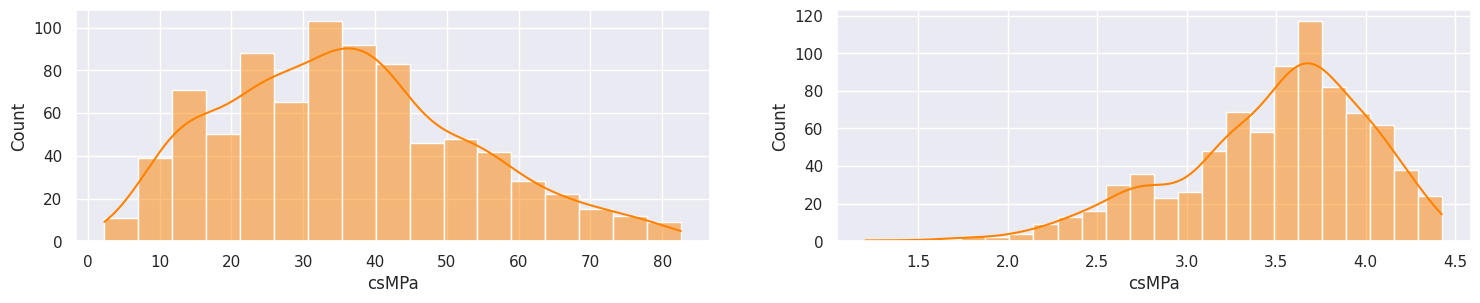

In [83]:
plt.figure(figsize = (18, 3)) #Ajuste o tamanho conforme necessário

#csMPa
plt.subplot(1, 2, 1)
sns.histplot(x = 'csMPa', data = df4, kde = True)

plt.subplot(1, 2, 2)
sns.histplot(x = 'csMPa', data = df5, kde = True);

In [29]:
df5.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
995,0.252511,0.000000,0.501749,0.300319,0.322981,0.589535,0.777220,0.151099,3.815512
507,0.424658,0.336672,0.000000,0.440895,0.217391,0.311047,0.589563,0.074176,3.764219
334,0.527397,0.000000,0.000000,0.560703,0.000000,0.378488,0.623683,0.074176,3.495598
848,0.343151,0.000000,0.493753,0.195687,0.440994,0.543023,0.740090,0.035714,3.767922
294,0.851598,0.000000,0.000000,0.848243,0.000000,0.380814,0.000000,0.739011,3.764219


#### 5.1.2 Dados de teste

In [30]:
dados_orig = pd.concat([x_teste, y_teste], axis = 1)

In [31]:
x_teste.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
31,149.0,236.0,0.0,176.0,13.0,847.0,893.0,28
109,480.0,0.0,0.0,192.0,0.0,936.0,721.0,3
136,307.0,0.0,0.0,193.0,0.0,968.0,812.0,90
88,200.0,133.0,0.0,192.0,0.0,965.4,806.2,3
918,318.8,212.5,0.0,155.7,14.3,852.1,880.4,56


In [32]:
#cement
x_teste['cement'] = mms_cement.transform(x_teste[['cement']].values) 

#slag
x_teste['slag'] = mms_slag.transform(x_teste[['slag']].values) 

#flyash
x_teste['flyash'] = mms_flyash.transform(x_teste[['flyash']].values) 

#water
x_teste['water'] = mms_water.transform(x_teste[['water']].values) 

#superplasticizer
x_teste['superplasticizer'] = mms_superplasticizer.transform(x_teste[['superplasticizer']].values) 

#coarseaggregate
x_teste['coarseaggregate'] = mms_coarseaggregate.transform(x_teste[['coarseaggregate']].values) 

#fineaggregate
x_teste['fineaggregate'] = mms_fineaggregate.transform(x_teste[['fineaggregate']].values) 

#age
x_teste['age'] = mms_age.transform(x_teste[['age']].values)

y_teste = np.array(y_teste).reshape(-1, 1)

#csMPa
y_teste = np.log1p(y_teste)

In [33]:
x_teste.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
31,0.107306,0.656650,0.0,0.432907,0.403727,0.133721,0.750125,0.074176
109,0.863014,0.000000,0.0,0.560703,0.000000,0.392442,0.318615,0.005495
136,0.468037,0.000000,0.0,0.568690,0.000000,0.485465,0.546914,0.244505
88,0.223744,0.370061,0.0,0.560703,0.000000,0.477907,0.532363,0.005495
918,0.494977,0.591263,0.0,0.270767,0.444099,0.148547,0.718515,0.151099


# 6. (Modelagem dos dados) Passo 6: Seleção das variáveis

In [34]:
df6 = df5.copy()

### 6.1 Selecionar as variáveis mais relevantes

#### 6.1.2 Importância das árvores

In [35]:
df6.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
995,0.252511,0.000000,0.501749,0.300319,0.322981,0.589535,0.777220,0.151099,3.815512
507,0.424658,0.336672,0.000000,0.440895,0.217391,0.311047,0.589563,0.074176,3.764219
334,0.527397,0.000000,0.000000,0.560703,0.000000,0.378488,0.623683,0.074176,3.495598
848,0.343151,0.000000,0.493753,0.195687,0.440994,0.543023,0.740090,0.035714,3.767922
294,0.851598,0.000000,0.000000,0.848243,0.000000,0.380814,0.000000,0.739011,3.764219


In [36]:
#Definição do modelo
forest = RandomForestRegressor(n_estimators = 200, random_state = 0, n_jobs = -1)

#Preparação dos dados
x_treino_n = df6.drop(['csMPa'], axis = 1)
y_treino_n = df6['csMPa'].values
forest.fit(x_treino_n, y_treino_n)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=0)

Rank das importâncias:
           Variavel  Importancia
0               age     0.371266
0            cement     0.349939
0              slag     0.070631
0             water     0.068450
0  superplasticizer     0.050659
0     fineaggregate     0.040703
0   coarseaggregate     0.029818
0            flyash     0.018533


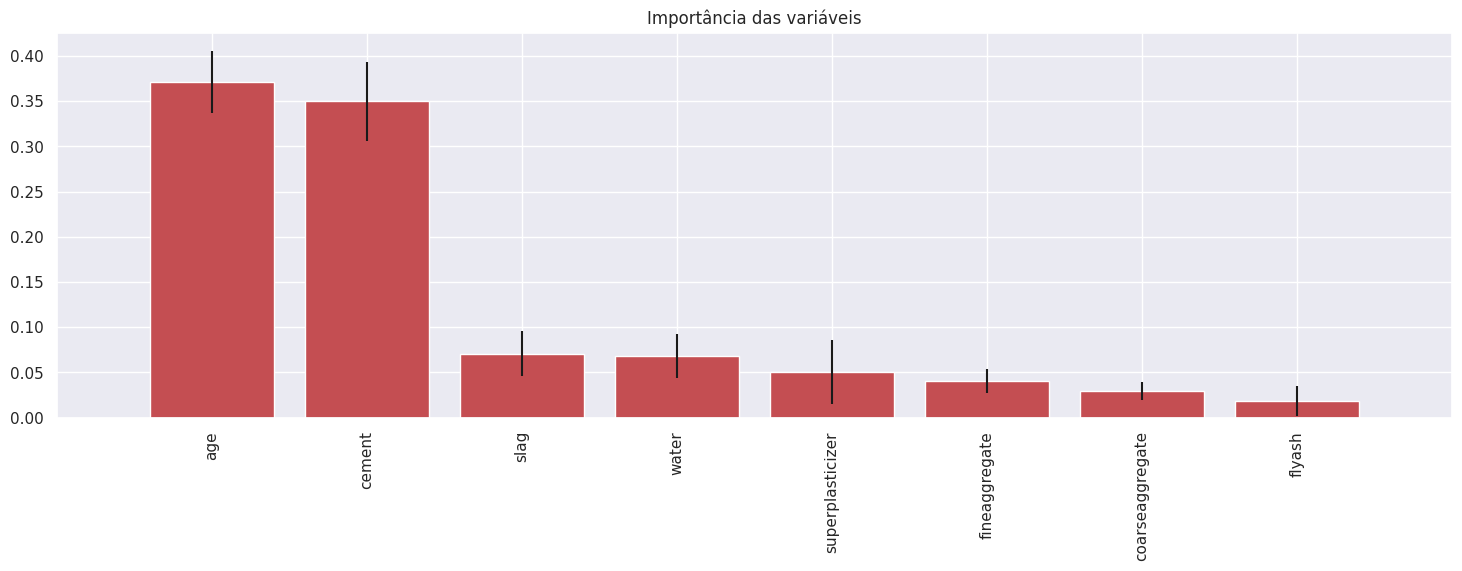

In [37]:
importancias = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importancias)[::-1]

# Imprimindo o rank das importâncias
print('Rank das importâncias:')
df = pd.DataFrame()
for i, j in zip(x_treino_n, forest.feature_importances_):
    aux = pd.DataFrame({'Variavel': i, 'Importancia': j}, index = [0])
    df = pd.concat([df, aux], axis = 0)

print(df.sort_values('Importancia', ascending=False))

# Plotando a impureza baseando-se na importância das variáveis
plt.figure(figsize = (18, 5))
plt.title('Importância das variáveis')

# Barra do gráfico com as importâncias
plt.bar(range(x_treino_n.shape[1]), importancias[indices], color ='r', yerr=std[indices], align = 'center')

# Definindo os rótulos do eixo x como os nomes das colunas
plt.xticks(range(x_treino_n.shape[1]), x_treino_n.columns[indices], rotation=90)

plt.xlim([-1, x_treino_n.shape[1]])
plt.show();

# 7. (Algoritmos de Ml) Passo 7: Implementar os modelos de machine learning

In [38]:
df7 = df6.copy()

In [39]:
df7.columns

Index(['cement', 'slag', 'flyash', 'water', 'superplasticizer',
       'coarseaggregate', 'fineaggregate', 'age', 'csMPa'],
      dtype='object')

In [40]:
colunas_selecionadas = ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age']
#colunas_selecionadas = ['cement', 'age']

x_treino = df7[colunas_selecionadas]
y_treino = df7['csMPa']

In [41]:
x_teste = x_teste[colunas_selecionadas]

In [42]:
x_teste.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
31,0.107306,0.656650,0.0,0.432907,0.403727,0.133721,0.750125,0.074176
109,0.863014,0.000000,0.0,0.560703,0.000000,0.392442,0.318615,0.005495
136,0.468037,0.000000,0.0,0.568690,0.000000,0.485465,0.546914,0.244505
88,0.223744,0.370061,0.0,0.560703,0.000000,0.477907,0.532363,0.005495
918,0.494977,0.591263,0.0,0.270767,0.444099,0.148547,0.718515,0.151099


In [43]:
x_treino.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
995,0.252511,0.000000,0.501749,0.300319,0.322981,0.589535,0.777220,0.151099
507,0.424658,0.336672,0.000000,0.440895,0.217391,0.311047,0.589563,0.074176
334,0.527397,0.000000,0.000000,0.560703,0.000000,0.378488,0.623683,0.074176
848,0.343151,0.000000,0.493753,0.195687,0.440994,0.543023,0.740090,0.035714
294,0.851598,0.000000,0.000000,0.848243,0.000000,0.380814,0.000000,0.739011


In [44]:
x_teste.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
31,0.107306,0.656650,0.0,0.432907,0.403727,0.133721,0.750125,0.074176
109,0.863014,0.000000,0.0,0.560703,0.000000,0.392442,0.318615,0.005495
136,0.468037,0.000000,0.0,0.568690,0.000000,0.485465,0.546914,0.244505
88,0.223744,0.370061,0.0,0.560703,0.000000,0.477907,0.532363,0.005495
918,0.494977,0.591263,0.0,0.270767,0.444099,0.148547,0.718515,0.151099


### 7.1 Algoritmo de Média (Baseline)

In [45]:
aux1 = x_treino.copy()
aux1['csMPa'] = y_treino.copy()

#Previsão
aux2 = aux1[['cement', 'csMPa']].groupby('cement').mean().reset_index().rename(columns = {'csMPa': 'predictions'})
aux1 = pd.merge(aux1, aux2, how = 'left',  on = 'cement')
y_pred_media = aux1['predictions']

#Resultado
resultado_media = ml_error(np.expm1(y_treino), np.expm1(y_pred_media.values), desvpad = False)
resultado_media = pd.DataFrame({'algoritmo': ['DummyRegressor'],
                                      'mae_cv': resultado_media['mae'],
                                      'mape_cv': resultado_media['mape'],
                                      'rmse_cv': resultado_media['rmse']}, index = [0])
resultado_media

,algoritmo,mae_cv,mape_cv,rmse_cv
0,DummyRegressor,8.51,0.31,11.10


### 7.2 Algoritmo Regressão linear

In [46]:
#Definindo o modelo
lr_modelo = lm.LinearRegression()

#Treinando o modelo com cross validation
y_pred_lr = validacao_cruzada(lr_modelo, x_treino, y_treino, desvpad = False, verbose = False)

#Resultado
y_pred_lr

,algoritmo,mae_cv,mape_cv,rmse_cv
0,LinearRegression,9.70,0.34,12.53


### 7.3 Algoritmo Regressão linear Lasso

In [47]:
#Definindo o modelo
lrr_modelo = Lasso(alpha = 0.01)

#Treinando o modelo com cross validation
y_pred_lrr = validacao_cruzada(lrr_modelo, x_treino, y_treino, desvpad = False, verbose = False)

#Resultado
y_pred_lrr

,algoritmo,mae_cv,mape_cv,rmse_cv
0,Lasso,10.01,0.37,12.42


### 7.4 Algoritmo Regressão linear Ridge

In [48]:
#Definindo o modelo
lrd_modelo = Ridge(alpha = 0.01)

#Treinando o modelo com cross validation
y_pred_lrd = validacao_cruzada(lrd_modelo, x_treino, y_treino, desvpad = False, verbose = False)

#Resultado
y_pred_lrd

,algoritmo,mae_cv,mape_cv,rmse_cv
0,Ridge,9.70,0.34,12.52


### 7.5 Algoritmo Extra trees

In [49]:
#Definindo o modelo
et_modelo = ExtraTreesRegressor(n_estimators = 100)

#Treinando o modelo com cross validation
y_pred_et = validacao_cruzada(et_modelo, x_treino, y_treino, desvpad = False, verbose = False)

#Resultado
y_pred_et

,algoritmo,mae_cv,mape_cv,rmse_cv
0,ExtraTreesRegressor,3.41,0.11,5.19


### 7.6 Algoritmo XGboost

In [50]:
#Definindo o modelo
xgb_modelo = xgb.XGBRegressor(n_estimators = 100)

#Treinando o modelo com cross validation
y_pred_xgb = validacao_cruzada(xgb_modelo, x_treino, y_treino, desvpad = False, verbose = False)

#Resultado
y_pred_xgb

,algoritmo,mae_cv,mape_cv,rmse_cv
0,XGBRegressor,3.22,0.11,4.79


### 7.7 Algoritmo SVR

In [51]:
#Definindo o modelo
svr_modelo = SVR(kernel = 'rbf', C = 1.0, epsilon = 0.1)

#Treinando o modelo com cross validation
y_pred_svr = validacao_cruzada(svr_modelo, x_treino, y_treino, desvpad = False, verbose = False)

#Resultado
y_pred_svr

,algoritmo,mae_cv,mape_cv,rmse_cv
0,SVR,5.85,0.21,7.51


### 7.8 Performance dos modelos

In [52]:
resultado = pd.concat([resultado_media, y_pred_lr, y_pred_lrr, y_pred_lrd, y_pred_et, y_pred_xgb, y_pred_svr], ignore_index = True)
resultado.sort_values('rmse_cv', ascending = False)

,algoritmo,mae_cv,mape_cv,rmse_cv
6,SVR,5.85,0.21,7.51
4,ExtraTreesRegressor,3.41,0.11,5.19
5,XGBRegressor,3.22,0.11,4.79
1,LinearRegression,9.70,0.34,12.53
3,Ridge,9.70,0.34,12.52
2,Lasso,10.01,0.37,12.42
0,DummyRegressor,8.51,0.31,11.10


# 8. (Algoritmos de Ml) Passo 8: Ajuste dos hiperparâmetros no algoritmo

### 8.1 <s>Bayesian search CV</s>

In [53]:
#Encontrando os melhores parâmetros 
#parametros = {'alpha': [0.0001, 0.001],
#              'tol': [0.0001, 0.001]}

In [54]:
# Instanciando o objeto GridSearchCV
#bayesian_search = BayesSearchCV(estimator = Ridge(),
#                                search_spaces = parametros,
#                                n_iter = 50,
#                                random_state = 42,
#                                n_jobs = -1,
#                                cv = 5)

# Treinando o modelo com a otimização
#bayesian_search.fit(x_treino, y_treino)

# Obtendo os melhores hiperparâmetros
#melhores_parametros = bayesian_search.best_params_

In [55]:
#melhores_parametros

### 8.1 Grid search CV

In [56]:
parametros = {'n_estimators': [100, 500],
              'learning_rate': [0.01, 0.1],
              'max_depth': [5],
              'gamma': [0.1, 0.5],
              'min_child_weight': [1, 3],
              'subsample': [0.5, 0.7],
              'colsample_bytree': [0.5, 0.7]}

In [57]:
# Função para calcular RMSE
def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))

# Criando o scorer
rmse_scorer = make_scorer(rmse, greater_is_better = False)

# Definindo o modelo
xgb_modelo = xgb.XGBRegressor()

# Instanciando o objeto GridSearchCV
grid_search = GridSearchCV(estimator = xgb_modelo,
                           param_grid = parametros,
                           scoring = rmse_scorer,
                           n_jobs = -1,
                           cv = 5,
                           verbose = 1)

# Treinando o modelo com a otimização
grid_search.fit(x_treino.values, y_treino.values)

# Obtendo os melhores hiperparâmetros
melhores_parametros = grid_search.best_params_

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.5, 0.7], 'gamma': [0.1, 0.5],
                         'learning_rate': [0.01, 0.1], 'max_depth': [5],
                         'min_child_weight': [1, 3], 'n_estimators': [100, 500],
                         'subsample': [0.5, 0.7]},
             scoring=make_scorer(rmse, greater_is_better=False, response_method='predict'),
             verbose=1)

In [58]:
melhores_parametros

{'colsample_bytree': 0.5,
 'gamma': 0.1,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 3,
 'n_estimators': 500,
 'subsample': 0.5}

### 8.2 Treinar modelo escolhido com os melhores parâmetros

In [59]:
#Definindo o modelo
xgb_modelo = xgb.XGBRegressor(**melhores_parametros)

#Treinando o modelo com cross validation
xgb_modelo.fit(x_treino, y_treino)

#Predição do modelo
y_pred_xgb = xgb_modelo.predict(x_teste)

aux = pd.DataFrame({'algoritmo': 'XGBRegressor'}, index = [0])

#Treinando o modelo com cross validation
resultado = pd.concat([aux, ml_error(np.expm1(y_teste), np.expm1(y_pred_xgb), desvpad = False)], axis = 1)

#Resultado
resultado

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

,algoritmo,mae,mape,rmse
0,XGBRegressor,3.40,0.66,4.79


# 9. (Avaliação do algoritmo) Passo 9: Performance do negócio ROI

**MAE:** (Erro Absoluto Médio) calcula a média da diferença absoluta entre os valores previstos (y_pred) e os valores reais (y).  
É interpretado como a média das magnitudes dos erros de previsão.  
**Exemplo:** Em média, suas previsões estão a (x) unidades de distância do valor real. Ou seja, seus modelos estão subestimando ou superestimando o valor real em uma média de (x) unidades.
    
**MAPE:** (Erro Absoluto Percentual Médio) calcula a média dos erros absolutos relativos (porcentagem).  
É interpretado como a média percentual dos erros de previsão em relação aos valores reais.  
**Exemplo:** Em média, suas previsões estão erradas em (x %) em relação ao valor real. Isso significa que, em média, seus modelos estão prevendo valores que são (x %) maiores ou menores que o valor real.

In [60]:
np.expm1(y_treino.loc[354])

10.220000000000002

In [61]:
# Dados inseridos manualmente
dados_manuais = np.array([[0.349315,0.0,0.0,0.560703,0.0,0.25814,0.880582,0.016484]])

# Fazer a previsão com os dados inseridos manualmente
y_pred = xgb_modelo.predict(dados_manuais)

# Imprimir a previsão
print("Predição:", np.expm1(y_pred))

Predição: [11.400188]


In [62]:
dados_orig['prediction'] = np.expm1(y_pred_xgb)
dados_orig['prediction'] = dados_orig['prediction'].round(2)
pd.options.display.float_format = '{:.2f}'.format

In [63]:
dados_orig.drop(columns = 'csMPa', axis = 1).head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,prediction
31,149.00,236.00,0.00,176.00,13.00,847.00,893.00,28,31.82
109,480.00,0.00,0.00,192.00,0.00,936.00,721.00,3,20.53
136,307.00,0.00,0.00,193.00,0.00,968.00,812.00,90,34.97
88,200.00,133.00,0.00,192.00,0.00,965.40,806.20,3,9.96
918,318.80,212.50,0.00,155.70,14.30,852.10,880.40,56,60.74


In [64]:
dados_orig_cost = pd.DataFrame()

dados_orig_cost['cement_cost'] = dados_orig['cement'] * 12
dados_orig_cost['slag_cost'] = dados_orig['slag'] * 15
dados_orig_cost['flyash_cost'] = dados_orig['flyash'] * 8
dados_orig_cost['water_cost'] = dados_orig['water'] * 5
dados_orig_cost['superplasticizer_cost'] = dados_orig['superplasticizer'] * 18
dados_orig_cost['coarseaggregate_cost'] = dados_orig['coarseaggregate'] * 12
dados_orig_cost['fineaggregate_cost'] = dados_orig['fineaggregate'] * 13
dados_orig_cost['age_cost'] = dados_orig['age'] * 5
dados_orig_cost['total_cost'] = dados_orig_cost.sum(axis = 1)
dados_orig_cost['prediction'] = dados_orig['prediction']

In [65]:
dados_orig_cost.head()

,cement_cost,slag_cost,flyash_cost,water_cost,superplasticizer_cost,coarseaggregate_cost,fineaggregate_cost,age_cost,total_cost,prediction
31,1788.00,3540.00,0.00,880.00,234.00,10164.00,11609.00,140,28355.00,31.82
109,5760.00,0.00,0.00,960.00,0.00,11232.00,9373.00,15,27340.00,20.53
136,3684.00,0.00,0.00,965.00,0.00,11616.00,10556.00,450,27271.00,34.97
88,2400.00,1995.00,0.00,960.00,0.00,11584.80,10480.60,15,27435.40,9.96
918,3825.60,3187.50,0.00,778.50,257.40,10225.20,11445.20,280,29999.40,60.74


In [66]:
# Calcular o maior
maior_valor = dados_orig_cost['prediction'].max()

# Criar os bins
bins = list(np.arange(0, maior_valor + 1, 10))

# Definir os rótulos das faixas
labels = [f'{i:.2f}-{i+9.99:.2f}' for i in range(0, int(maior_valor), 10)]

# Criar uma nova coluna com as faixas
dados_orig_cost['intervalos_prediction'] = pd.cut(dados_orig_cost['prediction'], bins = bins, labels = labels)

dados_orig_cost[['intervalos_prediction', 'total_cost']].groupby('intervalos_prediction').sum().reset_index()

,intervalos_prediction,total_cost
0,0.00-9.99,110698.10
1,10.00-19.99,852736.70
2,20.00-29.99,1096770.70
3,30.00-39.99,1841145.00
4,40.00-49.99,972430.80
5,50.00-59.99,457636.80
6,60.00-69.99,237918.00
7,70.00-79.99,148232.30


In [67]:
intervalos_70_79_aux = dados_orig_cost.loc[dados_orig_cost['intervalos_prediction'] == '70.00-79.99', ['intervalos_prediction', 'total_cost']].sort_values('total_cost', ascending = True)
intervalos_70_79 = pd.concat([intervalos_70_79_aux.iloc[0, :], intervalos_70_79_aux.iloc[-1, :]], axis = 1).T
intervalos_70_79['variacao_%'] = 1 - (intervalos_70_79['total_cost'].min() / intervalos_70_79['total_cost'].max())

intervalos_60_69_aux = dados_orig_cost.loc[dados_orig_cost['intervalos_prediction'] == '60.00-69.99', ['intervalos_prediction', 'total_cost']].sort_values('total_cost', ascending = True)
intervalos_60_69 = pd.concat([intervalos_60_69_aux.iloc[0, :], intervalos_60_69_aux.iloc[-1, :]], axis = 1).T
intervalos_60_69['variacao_%'] = 1 - (intervalos_60_69['total_cost'].min() / intervalos_60_69['total_cost'].max())

intervalos_50_59_aux = dados_orig_cost.loc[dados_orig_cost['intervalos_prediction'] == '50.00-59.99', ['intervalos_prediction', 'total_cost']].sort_values('total_cost', ascending = True)
intervalos_50_59 = pd.concat([intervalos_50_59_aux.iloc[0, :], intervalos_50_59_aux.iloc[-1, :]], axis = 1).T
intervalos_50_59['variacao_%'] = 1 - (intervalos_50_59['total_cost'].min() / intervalos_50_59['total_cost'].max())

intervalos_40_49_aux = dados_orig_cost.loc[dados_orig_cost['intervalos_prediction'] == '40.00-49.99', ['intervalos_prediction', 'total_cost']].sort_values('total_cost', ascending = True)
intervalos_40_49 = pd.concat([intervalos_40_49_aux.iloc[0, :], intervalos_40_49_aux.iloc[-1, :]], axis = 1).T
intervalos_40_49['variacao_%'] = 1 - (intervalos_40_49['total_cost'].min() / intervalos_40_49['total_cost'].max())

intervalos_30_39_aux = dados_orig_cost.loc[dados_orig_cost['intervalos_prediction'] == '30.00-39.99', ['intervalos_prediction', 'total_cost']].sort_values('total_cost', ascending = True)
intervalos_30_39 = pd.concat([intervalos_30_39_aux.iloc[0, :], intervalos_30_39_aux.iloc[-1, :]], axis = 1).T
intervalos_30_39['variacao_%'] = 1 - (intervalos_30_39['total_cost'].min() / intervalos_30_39['total_cost'].max())

intervalos_20_29_aux = dados_orig_cost.loc[dados_orig_cost['intervalos_prediction'] == '20.00-29.99', ['intervalos_prediction', 'total_cost']].sort_values('total_cost', ascending = True)
intervalos_20_29 = pd.concat([intervalos_20_29_aux.iloc[0, :], intervalos_20_29_aux.iloc[-1, :]], axis = 1).T
intervalos_20_29['variacao_%'] = 1 - (intervalos_20_29['total_cost'].min() / intervalos_20_29['total_cost'].max())

intervalos_10_19_aux = dados_orig_cost.loc[dados_orig_cost['intervalos_prediction'] == '10.00-19.99', ['intervalos_prediction', 'total_cost']].sort_values('total_cost', ascending = True)
intervalos_10_19 = pd.concat([intervalos_10_19_aux.iloc[0, :], intervalos_10_19_aux.iloc[-1, :]], axis = 1).T
intervalos_10_19['variacao_%'] = 1 - (intervalos_10_19['total_cost'].min() / intervalos_10_19['total_cost'].max())

intervalos_0_9_aux = dados_orig_cost.loc[dados_orig_cost['intervalos_prediction'] == '0.00-9.99', ['intervalos_prediction', 'total_cost']].sort_values('total_cost', ascending = True)
intervalos_0_9 = pd.concat([intervalos_0_9_aux.iloc[0, :], intervalos_0_9_aux.iloc[-1, :]], axis = 1).T
intervalos_0_9['variacao_%'] = 1 - (intervalos_0_9['total_cost'].min() / intervalos_0_9['total_cost'].max())

In [68]:
resultado = pd.concat([intervalos_0_9, intervalos_10_19, intervalos_20_29, intervalos_30_39, intervalos_40_49, intervalos_50_59, intervalos_60_69, intervalos_70_79], axis = 0)

In [69]:
resultado

,intervalos_prediction,total_cost,variacao_%
208,0.00-9.99,27126.80,0.06
394,0.00-9.99,28844.90,0.06
66,10.00-19.99,25896.20,0.11
423,10.00-19.99,28991.40,0.11
485,20.00-29.99,25506.00,0.12
912,20.00-29.99,28994.40,0.12
989,30.00-39.99,25928.90,0.12
745,30.00-39.99,29396.30,0.12
96,40.00-49.99,25962.00,0.14
853,40.00-49.99,30125.20,0.14


# 10. (Modelo em produção) Passo 10 Modelo em produção

### 10.1 Salvar o modelo em Pickle

In [70]:
# Nome do bucket
bucket_name = 'armazenamento-qualidade-concreto'

# Caminho completo dentro do bucket
blob_path = 'modelo/modelo_treinado.pkl'

# Inicialize o cliente do Google Cloud Storage
storage_client = storage.Client()

# Acesse o bucket
bucket = storage_client.bucket(bucket_name)

# Serialize o modelo para bytes
modelo_bytes = pickle.dumps(xgb_modelo)

# Carregue os bytes no bucket
blob = bucket.blob(blob_path)
blob.upload_from_string(modelo_bytes)

### 10.2 Salvar as transformações em Pickle

In [71]:
# Lista de nomes das variáveis
variaveis = ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age']

# Inicialize o cliente do Google Cloud Storage
storage_client = storage.Client()

# Nome do bucket
bucket_name = 'armazenamento-qualidade-concreto'

# Caminho do diretório do modelo dentro do bucket
transformacoes = 'transformacoes/'

# Iterar sobre as variáveis
for variavel in variaveis:
    # Criar e ajustar o MinMaxScaler para a variável atual
    mms = MinMaxScaler()
    df5[variavel] = mms.fit_transform(df5[[variavel]].values)
    
    # Caminho completo dentro do bucket para a transformação
    blob_path = f'{transformacoes}{variavel}_mms.pkl'

    # Serialize a transformação para bytes
    transformacao_bytes = pickle.dumps(mms)

    # Acesse o bucket
    bucket = storage_client.bucket(bucket_name)

    # Carregue os bytes no bucket
    blob = bucket.blob(blob_path)
    blob.upload_from_string(transformacao_bytes)

NameError: name 'MinMaxScaler' is not defined

### 10.3 Classe do projeto (salvar em arquivo.py)

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import statsmodels.api as sm
import skopt
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from ydata_profiling import ProfileReport
from google.cloud import storage

# Lista de outras bibliotecas
bibliotecas = {
    'pandas': pd,
    'numpy': np,
    'xgboost': xgb,
    'seaborn': sns,
    'sklearn': sklearn,
    'matplotlib': plt,
    'statsmodels': sm,
    'skopt': skopt,
    'SVR': SVR,
    'DummyRegressor': DummyRegressor,
    'ProfileReport': ProfileReport,
    'storage': storage
}

# Imprimir versões de todas as bibliotecas
for nome, biblioteca in bibliotecas.items():
    if hasattr(biblioteca, '__version__'):
        print(f'Versão de {nome}: {biblioteca.__version__}')


In [ ]:
!requests --version

In [ ]:
gs://armazenamento-qualidade-concreto/age_mms.pkl

In [ ]:
import pickle
import pandas as pd
import numpy as np

class HealthInsurance:
    def __init__(self):
        #Colocando os caminhos dos arquivos que foram transformados e salvos no Pickle
        self.home_path = '/home/leonardo/projetos_/propensao_de_compra/API/'
        self.Annual_Premium_scaler = pickle.load(open(self.home_path + 'transformacoes/Annual_Premium_scaler.pkl', 'rb'))
        self.Age_scaler = pickle.load(open(self.home_path + 'transformacoes/Age_scaler.pkl', 'rb'))
        self.Vintage_scaler = pickle.load(open(self.home_path + 'transformacoes/Vintage_scaler.pkl', 'rb'))
        self.Gender_scaler = pickle.load(open(self.home_path + 'transformacoes/Gender_scaler.pkl', 'rb'))
        self.Region_Code_scaler = pickle.load(open(self.home_path + 'transformacoes/Region_Code_scaler.pkl', 'rb'))
        self.Policy_Sales_Channel_scaler = pickle.load(open(self.home_path + 'transformacoes/Policy_Sales_Channel_scaler.pkl', 'rb'))

    def engenharia_de_atributos(self, df1):
        #Alterando os dados da coluna 'Vehicle_Age' e 'Vehicle_Damage'
        df1['Vehicle_Age'] = df1['Vehicle_Age'].apply(lambda x: 'over_2_years' if x == '> 2 Years' else 'between_1_2_year' if x == '1-2 Year' else 'below_1_year')
        df1['Vehicle_Damage'] = df1['Vehicle_Damage'].apply(lambda x: 1 if x == 'Yes' else 0)
        return df1

    def modelagem_dos_dados(self, df5):
        #Annual_Premium
        df5['Annual_Premium'] = self.Annual_Premium_scaler.transform(df5[['Annual_Premium']].values) #Precisa passar um array

        #Age
        df5['Age'] = self.Age_scaler.transform(df5[['Age']].values) #Precisa passar um array

        #Vintage
        df5['Vintage'] = self.Vintage_scaler.transform(df5[['Vintage']].values) #Precisa passar um array

        #Gender -> Target Encoding
        #Target Encoding
        df5.loc[:, 'Gender'] = df5['Gender'].map(self.Gender_scaler)

        #Region_Code -> Target Encoding
        #Target Encoding
        df5.loc[:, 'Region_Code'] = df5['Region_Code'].map(self.Region_Code_scaler)

        #Vehicle_Age -> One Hot Encoding ou Ordinal Encoding
        #One Hot Encoding
        df5 = pd.get_dummies(df5, prefix='Vehicle_Age', columns=['Vehicle_Age'])

        #Policy_Sales_Channel -> Target Encoding ou Frequency Encoding
        #Frequency Encoding
        df5.loc[:, 'Policy_Sales_Channel'] = df5['Policy_Sales_Channel'].map(self.Policy_Sales_Channel_scaler)

        #Colunas selecionadas a partir a importância das variáveis
        colunas_selecionadas = ['Annual_Premium',
                                'Vintage',
                                'Age',
                                'Region_Code',
                                'Vehicle_Damage',
                                'Policy_Sales_Channel',
                                'Previously_Insured']
        return df5[colunas_selecionadas]

    def get_prediction(self, modelo, dados_original, dados_teste):
        #Predição
        pred = modelo.predict_proba(dados_teste)

        #Juntando a predição com os dados originais
        dados_original['Score'] = pred[:, 1].tolist()

        return dados_original.to_json(orient = 'records', date_format = 'iso')